## Del 1 – Grundläggande analys och statistik

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/health_study_dataset.csv")

df.head(3)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [2]:
na_counts = df.isna().sum()
print("\nSaknade värden per kolumn:")
print(na_counts)


Saknade värden per kolumn:
id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64


In [3]:
df.duplicated().any()

np.False_

### Räknar ut medel, median, min och max :

In [4]:
columns = ["age", "weight", "height", "systolic_bp", "cholesterol"].copy()
for column in columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")


In [5]:
df[columns].dtypes

age              int64
weight         float64
height         float64
systolic_bp    float64
cholesterol    float64
dtype: object

In [6]:
summary = df[columns].agg(["mean", "median", "min", "max"])
print(summary)

             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


### 3 grafer till

In [7]:
plt.rcParams["figure.figsize"] = (8,5)   # sätter lite standardvärden för alla grafer, storlek, skärpan på grafer, osv. 
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3)
pd.set_option("display.precision", 3)

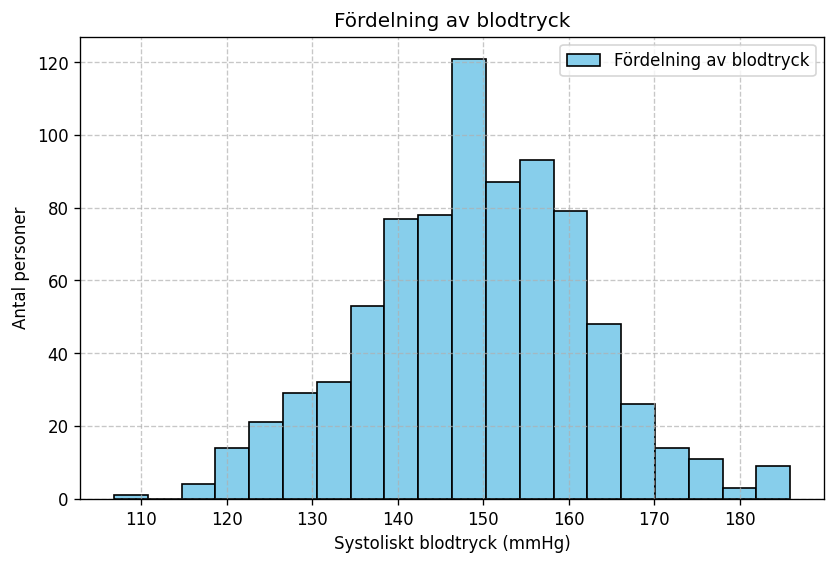

In [8]:
fig, ax = plt.subplots()

ax.hist(df["systolic_bp"], bins =20, label= "Fördelning av blodtryck", color="skyblue", edgecolor="black")
ax.set_title("Fördelning av blodtryck")
ax.set_xlabel("Systoliskt blodtryck (mmHg)")
ax.set_ylabel("Antal personer")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend()
plt.show()

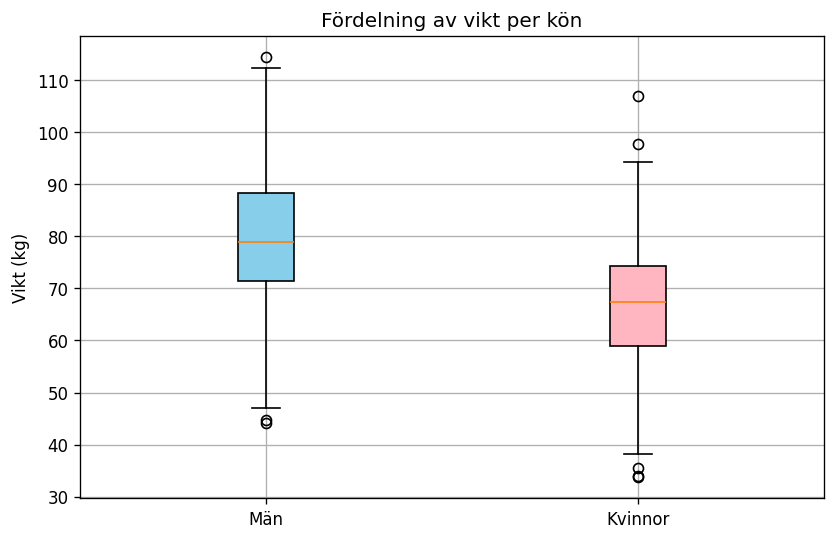

In [9]:
fig, ax = plt.subplots()

box = ax.boxplot(
    [df.loc[df["sex"] == "M", "weight"],
            df.loc[df["sex"] == "F", "weight"]],
            patch_artist=True,
            tick_labels = ["Män", "Kvinnor"])

colors= ["skyblue", "lightpink"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

ax.set_title("Fördelning av vikt per kön")
ax.set_ylabel("Vikt (kg)")
plt.show()

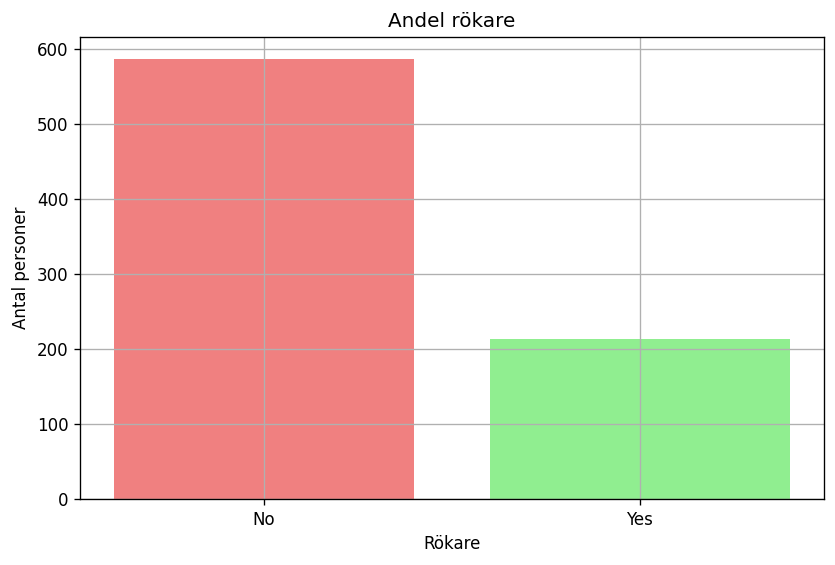

In [10]:
smoker_counts = df["smoker"].value_counts()

fig, ax = plt.subplots()

ax.bar(smoker_counts.index, smoker_counts.values, color=["lightcoral", "lightgreen"])
ax.set_title("Andel rökare")
ax.set_xlabel("Rökare")
ax.set_ylabel("Antal personer")
plt.show()

### Andel personer som har sjukdom

In [11]:
andel_sjuka = df["disease"].mean()
print("Andel sjuka i datasetet: ", andel_sjuka)

Andel sjuka i datasetet:  0.05875


In [12]:
# alltså cirka 6% har sjukdomen

In [13]:
np.random.seed(42)
simulated= np.random.choice([0, 1], size=1000, p=[1-andel_sjuka, andel_sjuka])

simulated_rate = simulated.mean()
print("Andelen sjuka i simuleringen:", simulated_rate)

Andelen sjuka i simuleringen: 0.056


In [14]:
print(f"Verklig andel:      {andel_sjuka*100:.1f}%")
print(f"Simulerad andel:    { simulated_rate*100:.1f}%   ")

Verklig andel:      5.9%
Simulerad andel:    5.6%   


In [15]:
# inte stor skillnad alls mellan dessa

### Konfidensintervall för medelvärdet av systolic_bp

In [16]:
# Jag kommer att använda mig av normalapproximation som känns lite lättare:

In [17]:
x = df["systolic_bp"].to_numpy()
n = len(x)
mean = x.mean()
std = x.std(ddof=1)
se = std / np.sqrt(n)
z = 1.96

ci_low = mean - z*se
ci_high = mean + z*se

print(f"Medel:  {mean:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

Medel:  149.18
95% CI: [148.29, 150.07]


In [18]:
# Det visades att sanna medelvärde befinner sig i intervallet jag fick fram. Det kan vi vara 95% säkra på.

### Hypotesprövning 
Testar om rökare har högre medel-blodtryck än icke rökare.

In [19]:
if df["smoker"].dtype == "0":
    df["smoker"] = df["smoker"].map({"Yes": 1, "No": 0}) # det här funkar inte riktigt för mig, testar annat istället:

if df["smoker"].dtype == object :
    df["smoker"] = (
        df["smoker"].astype(str).str.strip()
        .map({"Yes": 1, "No": 0, "1":1, "0":0})
        .astype(int)
    )

bp_smoke = df.loc[df["smoker"] == 1, "systolic_bp"].to_numpy()
bp_not_smoke = df.loc[df["smoker"] == 0, "systolic_bp"].to_numpy()

mean_smoke = bp_smoke.mean()
mean_not_smoke = bp_not_smoke.mean()
obs_diff = mean_smoke - mean_not_smoke

n1 = bp_smoke.size
n2 = bp_not_smoke.size

print(f"rökare: {n1}, icke-rökare {n2}")
print(f"Medel rökare: {mean_smoke:.2f}")
print(f"Medel icke-rökare: {mean_not_smoke:.2f}")
print(f"Observerad skillnad: {obs_diff:.2f}")

rökare: 213, icke-rökare 587
Medel rökare: 149.52
Medel icke-rökare: 149.05
Observerad skillnad: 0.47


In [20]:
rng = np.random.default_rng(42)

all_bp = np.concatenate([bp_smoke, bp_not_smoke])
B = 10_000
"""
B= Antalet bootstrap alltså hur många gånger drar slumpen.
"""

count = 0
for _ in range(B):
    idx = rng.permutation(all_bp.size)
    group1 = all_bp[idx[:n1]]
    group2 = all_bp[idx[n1:]]
    diff = group1.mean() - group2.mean()
    if diff >= obs_diff:
        count +=1

p_value = (count + 1) / (B + 1)
print(f"p-värde (en-sidigt, permutation): {p_value:.4f}")

p-värde (en-sidigt, permutation): 0.3246


In [21]:
alpha = 0.05
p_value = 0.3246

if p_value > alpha:
    write = "Resultatet tyder på att rökare har högre medel-blodtryck än icke-rökare"
else:
    write = "Hittar inget tydligt stöd för att rökare har högre medel-blodtryck än icke-rökare"

print(write)

Resultatet tyder på att rökare har högre medel-blodtryck än icke-rökare


### Resultat
Jag gjorde ett test för att se om rökare har högre medel- blodtryck än icke-rökare. Resultatet gav ett p-värde på 0.3246, vilket betyder att det är ganska osannolikt att skillnaden beror på slumpen. Jag tolkar det som att rökare verkar ha högre blodtryck enligt denna data i den här studien. 

# FÖR VG:

### Räknar konfidensintervall med normalapproximation:

In [22]:
# mitt favorit sätt att räkna konfidensintervall på:

In [23]:
from scipy import stats
from math import sqrt

In [24]:
def ci_norm(x, confidence=0.95):
    """
    95%-CI för medel med normal-approximation:
    medel ± 1.96 * (s / sqrt(n))
    """
    n = len(x)
    m = np.mean(x)
    s = np.std(x, ddof=1)
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha /2)

    half_width = z * s / np.sqrt(n)
    lo, hi = m - half_width, m + half_width
    return lo, hi, m, s, n

x = df["systolic_bp"].dropna().to_numpy()
lo, hi, m, s, n = ci_norm(x)
print(lo, hi)


148.2921066505355 150.06514334946453


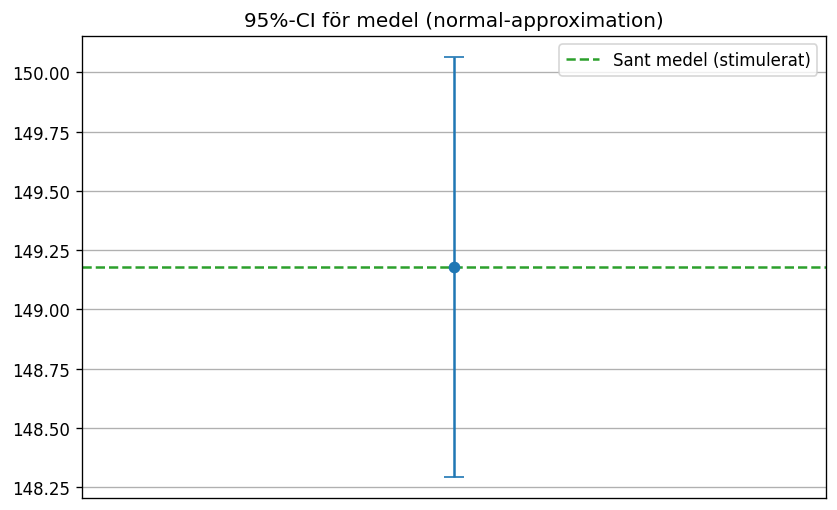

In [25]:
fig, ax = plt.subplots()
ax.errorbar([0], [m], yerr=[[m - lo], [hi - m]], fmt="o", capsize=6)             # yerr = ritar ut felstaplarna; fmt gjorde punkten i mitten; capsize gjorde hattarna
ax.axhline(m, color="tab:green", linestyle="--", label="Sant medel (stimulerat)")
ax.set_xticks([])
ax.grid(True, axis="y")
ax.legend()
ax.set_title("95%-CI för medel (normal-approximation)")

plt.show()

### Räknar konfidensintervall med bootstrap:

In [26]:
def ci_bootstrap(x, confidence=0.95, B=10_000, seed=42):
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(B, len(x)), replace=True).mean(axis=1)
    alpha = 1 - confidence
    lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2])
    return lo,hi,boots.mean(), boots

In [27]:
# Jämför båda :

x = df["systolic_bp"].dropna().to_numpy()

lo_n, hi_n, m_n, *_ = ci_norm(x)
lo_b, hi_b, m_b, boots = ci_bootstrap(x)

print(f"Normal CI:      ({lo_n:.2f}, {hi_n:.2f}) mean={m_n:.2f}")
print(f"Bootstrap CI:   ({lo_b:.2f}, {hi_b:.2f} mean_boot={m_b:.2f})")

Normal CI:      (148.29, 150.07) mean=149.18
Bootstrap CI:   (148.31, 150.05 mean_boot=149.19)


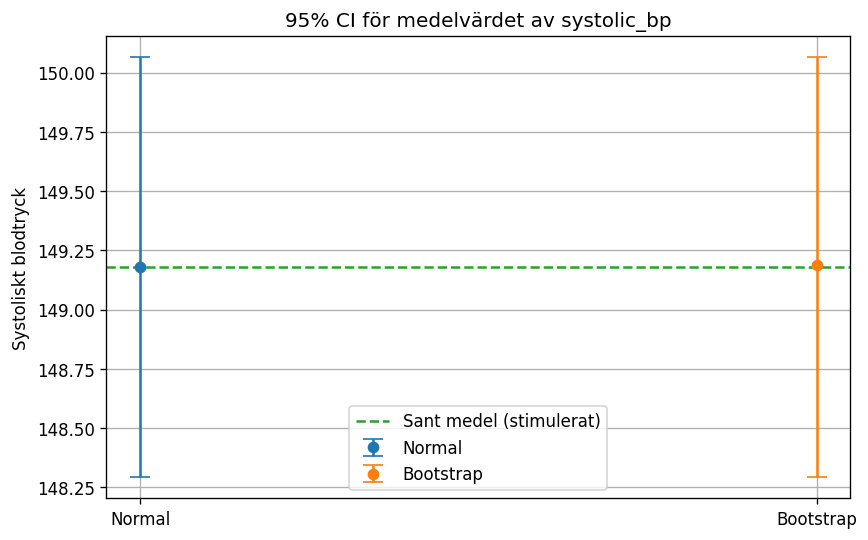

In [28]:
# testar att lägga båda i samma graf för bättre jämförelse:

fig, ax = plt.subplots()
ax.errorbar([0], [m_n], yerr=[[m_n - lo], [hi - m_n]], fmt="o", capsize=6, label="Normal")  

ax.errorbar([1], [m_b], yerr=[[m_b - lo], [hi - m_b]], fmt="o", capsize=6, label="Bootstrap")

ax.axhline(m, color="tab:green", linestyle="--", label="Sant medel (stimulerat)")

ax.set_xticks([0,1])
ax.set_xticklabels(["Normal", "Bootstrap"])
ax.set_ylabel("Systoliskt blodtryck")
ax.set_title("95% CI för medelvärdet av systolic_bp")
ax.grid(True, axis="y")
ax.legend()

plt.show()

Jag använde mig av två metoder för att beräkna 95 % konfidensintervall: normalapproximation och bootstrap. Man kan se att siffrorna skiljer sig lite lite grann mellan normalmetoden och Bootstrap metoden. 
Normalmetoden är snabb medans den andra är väldigt flexibel och robust att använda. 

Eftersom intervallen blev ganska lika i det här fallet:

Normal CI:      (148.29, 150.07) mean=149.18

Bootstrap CI:   (148.31, 150.05 mean_boot=149.19),

betyder det att normalapproximationen fungerar utmärkt för detta dataset. Bootstrap resultatet (som slumpmässigt använder datan många gånger och beräknar intervallet) bekräftar att resultaten är ganska lika, känns det lite mer robust om datan skulle vara skev eller konstigt fördelad. 

### Hur säker är hypotestestet?

In [32]:
def power(df, column= "systolic_bp", group_column="smoker", alpha=0.05, R=5000, seed=123):
    rng = np.random.default_rng(seed)
    g1 = df.loc[df[group_column] == 1, column].dropna().to_numpy()  # det här blir för rökare
    g0 = df.loc[df[group_column] == 0, column].dropna().to_numpy()  # det här blir för icke-rökare
    
    n1, n0 = len(g1), len(g0)
    m1, sd1 = g1.mean(), g1.std(ddof=1)
    m0, sd0 = g0.mean(), g0.std(ddof=1)
    
    hits = 0
    for _ in range(R):
        x1 = rng.normal(m1,sd1,n1)
        x0 = rng.normal(m0,sd0,n0)
        stat, p = stats.ttest_ind(x1, x0, equal_var=False, alternative="greater")
        hits += (p < alpha)
    return hits / R, (n1, n0), (m1 - m0)

power_par, ns, diff_hat = power(df)
print(f"Parametrisk power ≈ {power_par:.3f} (n_rökare={ns[0]}, n_icke={ns[1]}, skattad effekt={diff_hat:.2f})")

Parametrisk power ≈ 0.115 (n_rökare=213, n_icke=587, skattad effekt=0.47)


Power förklarar varför små eller brusiga studier kan missa verkliga effekter.
Chansen att vi hittar en effekt, när den faktiskt finns. Om power är hög så betyder det att vi ofta kommer att upptäcka effekt när den finns, är den låg så missar vi den ofta och riskerar att missa en verklig skillnad. Det kallas för ett typ två fel eller ett falskt negativ som läraren förklarade i videon.  Ingen resultat inte alltid betyder ingen effekt. Ibland har kanske en studie för låg power?

Jag gjorde en simulering av power för :
**" Rökare har högre medelblodtryck än icke-rökare"**
och fick som resultat ≈ 0.115.

Det betyder att testet har bara cirka 11.5% chans att upptäcka en verklig skillnad av den här storleken med nuvarande datamängd. 
Jag tycker att det är en ganska låg power som resulterar med att vi riskerar att missa en verklig effekt om den finns. Effekten ser lovande ut, men det är inte tillräckligt säkert. Vi bör fortsätta experimentet och samla in mer data. Man hade behövt samla några hundra till per grupp ( rökare och ej rökare) för att få ut rätt power.

- Jag använde en del från https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html. Kursanteckningar om power och typ II-fel. 
- Fick hjälp av lärarens olika lektions-videos och mina egna anteckningar i notebook samt alla weeks exercises. 
